In [25]:
# ======================================================
# 1. Imports
# ======================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet169
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalMaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# ======================================================
# 2. Settings
# ======================================================
SEED = 9
IMG_SIZE = (256, 256)
BATCH_SIZE = 16  # Safe for Kaggle T4
DATA_DIR = "../input/airbus-ship-detection/train_v2"  # Adjust path
CSV_PATH = "../input/airbus-ship-detection/train_ship_segmentations_v2.csv"

# ======================================================
# 3. Load CSV & Sample 10k Images
# ======================================================
df = pd.read_csv(CSV_PATH)
# Add has_ship column: 1 if segmentation exists, else 0
df['has_ship'] = df['EncodedPixels'].notnull().astype(int)

# Randomly sample 10k images while keeping ship ratio
df_sample = df.groupby('has_ship', group_keys=False).apply(lambda x: x.sample(min(len(x), 5000), random_state=SEED))
df_sample = df_sample.reset_index(drop=True)

# Train/Val split 70/30
train_df = df_sample.sample(frac=0.7, random_state=SEED)
val_df = df_sample.drop(train_df.index).reset_index(drop=True)
train_df = train_df.reset_index(drop=True)

# Convert labels to strings for flow_from_dataframe
train_df["has_ship"] = train_df["has_ship"].astype(str)
val_df["has_ship"] = val_df["has_ship"].astype(str)

print(f"Train rows: {len(train_df)}, Val rows: {len(val_df)}")
print(f"Train ship ratio: {train_df['has_ship'].astype(int).mean():.4f}, Val ship ratio: {val_df['has_ship'].astype(int).mean():.4f}")

Train rows: 7000, Val rows: 3000
Train ship ratio: 0.4987, Val ship ratio: 0.5030


/tmp/ipykernel_37/1983104184.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df.groupby('has_ship', group_keys=False).apply(lambda x: x.sample(min(len(x), 5000), random_state=SEED))


In [26]:
# ======================================================
# 4. ImageDataGenerators
# ======================================================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=DATA_DIR,
    x_col="ImageId",
    y_col="has_ship",
    target_size=IMG_SIZE,
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    drop_remainder=True  # Important for single GPU / batch consistency
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=DATA_DIR,
    x_col="ImageId",
    y_col="has_ship",
    target_size=IMG_SIZE,
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_remainder=True
)

Found 7000 validated image filenames belonging to 2 classes.
Found 3000 validated image filenames belonging to 2 classes.


In [27]:
# ======================================================
# 5. TL-CNN Model (DenseNet169)
# ======================================================
base_model = DenseNet169(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))

x = base_model.output
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = GlobalMaxPooling2D()(x)
x = Dense(1664, activation='relu')(x)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid', dtype='float32')(x)  # force float32 for stability

model_tl = Model(inputs=base_model.input, outputs=output)

# Freeze base model first
for layer in base_model.layers:
    layer.trainable = False

model_tl.compile(optimizer=Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])
model_tl.summary()

# ======================================================
# 6. Callbacks
# ======================================================
checkpoint = ModelCheckpoint("tl_cnn_best.h5", monitor='val_loss', save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_4 (Cast)       │ (None, 256, 256,  │          0 │ input_layer_3[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_4    │ (None, 262, 262,  │          0 │ cast_4[0][0]      │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,408 │ zero_padding2d_4… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_5    │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 64, 64,    │          0 │ zero_padding2d_5… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 64, 64,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 64, 64,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 64, 64,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 64, 64,    │          0 │ conv2_block2_0_b

 Total params: 15,633,345 (59.64 MB)

 Trainable params: 2,987,137 (11.40 MB)

 Non-trainable params: 12,646,208 (48.24 MB)

In [28]:
# ======================================================
# 7. Train Model
# ======================================================
history = model_tl.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1760287988.262711      97 service.cc:148] XLA service 0x2849d6a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760287988.267988      97 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1760287988.268018      97 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


  2/438 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - accuracy: 0.5938 - loss: 2.0988   

I0000 00:00:1760288011.211634      97 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.8329 - loss: 0.4933
Epoch 1: val_loss improved from inf to 0.26727, saving model to tl_cnn_best.h5
438/438 ━━━━━━━━━━━━━━━━━━━━ 247s 441ms/step - accuracy: 0.8329 - loss: 0.4930 - val_accuracy: 0.9043 - val_loss: 0.2673 - learning_rate: 1.0000e-04
Epoch 2/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.8993 - loss: 0.2644
Epoch 2: val_loss improved from 0.26727 to 0.22981, saving model to tl_cnn_best.h5
438/438 ━━━━━━━━━━━━━━━━━━━━ 147s 336ms/step - accuracy: 0.8993 - loss: 0.2644 - val_accuracy: 0.9140 - val_loss: 0.2298 - learning_rate: 1.0000e-04
Epoch 3/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.9031 - loss: 0.2405
Epoch 3: val_loss improved from 0.22981 to 0.22046, saving model to tl_cnn_best.h5
438/438 ━━━━━━━━━━━━━━━━━━━━ 146s 333ms/step - accuracy: 0.9031 - loss: 0.2406 - val_accuracy: 0.9170 - val_loss: 0.2205 - learning_rate: 1.0000e-04
Epoch 4/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step -

In [31]:
# ======================================================
# 8. Threshold Scanning (Fixed)
# ======================================================
def threshold_scan(model, generator, thresholds=np.arange(0.1, 0.91, 0.1)):
    y_true = np.array(generator.labels).astype(int)  # convert list -> np.array
    y_pred_prob = model.predict(generator, verbose=0)
    best_acc = 0
    best_thresh = 0.5
    for t in thresholds:
        y_pred = (y_pred_prob >= t).astype(int)
        acc = accuracy_score(y_true, y_pred)
        if acc > best_acc:
            best_acc = acc
            best_thresh = t
    return best_thresh, best_acc, y_true, y_pred_prob

best_thresh, best_acc, y_true, y_pred_prob = threshold_scan(model_tl, val_generator)
print(f"Best threshold: {best_thresh}, Validation Accuracy: {best_acc:.4f}")

Best threshold: 0.6, Validation Accuracy: 0.9390


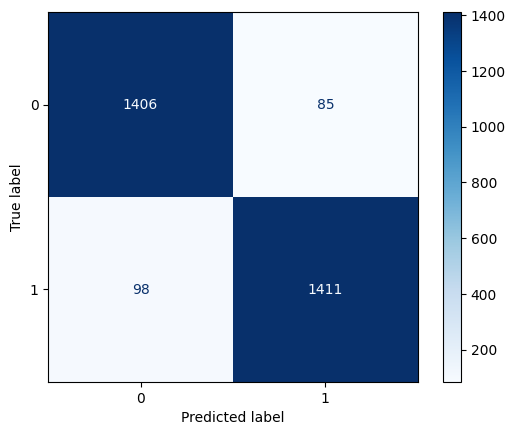

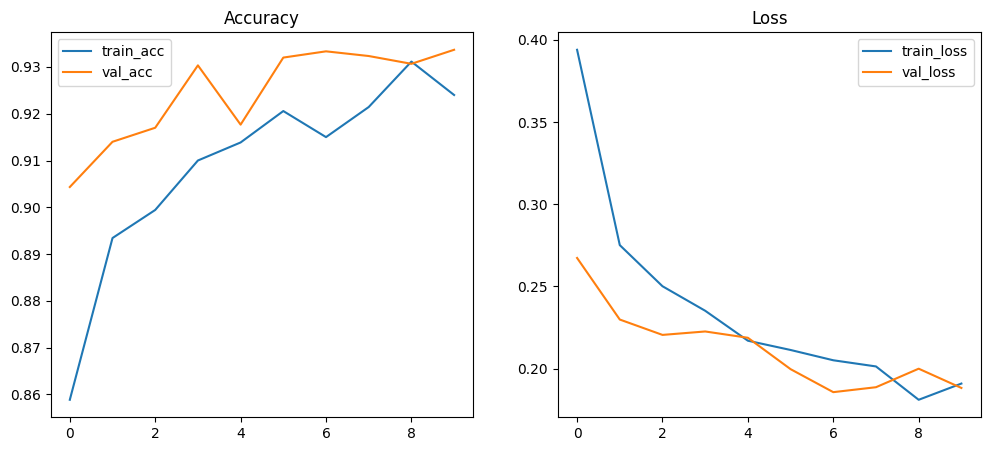

In [32]:
# ======================================================
# 9. Confusion Matrix
# ======================================================
y_pred_final = (y_pred_prob >= best_thresh).astype(int)
cm = confusion_matrix(y_true, y_pred_final)
disp = ConfusionMatrixDisplay(cm, display_labels=[0,1])
disp.plot(cmap=plt.cm.Blues)
plt.show()

# ======================================================
# 10. Accuracy / Loss Plots
# ======================================================
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title("Loss")
plt.legend()
plt.show()